In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
import pandas as pd

# Replace 'your_dataset.csv' with the path to your dataset file
data = pd.read_csv('kddcup.data_10_percent')

# Preview the dataset
print(data.head())


   0  tcp  http  SF  181  5450  0.1  0.2  0.3  0.4  ...  9.1  1.00.1  0.00.6  \
0  0  tcp  http  SF  239   486    0    0    0    0  ...   19     1.0     0.0   
1  0  tcp  http  SF  235  1337    0    0    0    0  ...   29     1.0     0.0   
2  0  tcp  http  SF  219  1337    0    0    0    0  ...   39     1.0     0.0   
3  0  tcp  http  SF  217  2032    0    0    0    0  ...   49     1.0     0.0   
4  0  tcp  http  SF  217  2032    0    0    0    0  ...   59     1.0     0.0   

   0.11  0.00.7  0.00.8  0.00.9  0.00.10  0.00.11  normal.  
0  0.05     0.0     0.0     0.0      0.0      0.0  normal.  
1  0.03     0.0     0.0     0.0      0.0      0.0  normal.  
2  0.03     0.0     0.0     0.0      0.0      0.0  normal.  
3  0.02     0.0     0.0     0.0      0.0      0.0  normal.  
4  0.02     0.0     0.0     0.0      0.0      0.0  normal.  

[5 rows x 42 columns]


In [3]:
num_samples = 10000
num_features = 41
num_classes = 5  # Number of classes
# Simulate random data for demonstration
X = np.random.rand(num_samples, num_features)
y = np.random.randint(0, num_classes, size=(num_samples,))


In [4]:
# Normalize the input features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
input_dim = 100
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
model.add(Dropout(0.5))  # Add Dropout layer with a dropout rate of 0.5
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Reshape X for Conv1D (add the channel dimension)
X = X[..., np.newaxis]  # Shape becomes (num_samples, num_features, 1)


In [7]:
# One-hot encode the labels
y = to_categorical(y, num_classes)


In [8]:
# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [9]:
# Step 2: Define the 1D CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(num_features, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.3),

    Conv1D(filters=256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Multi-class classification
])


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Step 3: Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [11]:
# Step 4: Train the model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

class_weights = {i: len(y_train) / (num_classes * np.sum(y_train == i)) for i in range(num_classes)}
model.fit(X_train, y_train, class_weight=class_weights)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=100,
                    batch_size=64,
                    callbacks=callbacks)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5124\2873761475.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  class_weights = {i: len(y_train) / (num_classes * np.sum(y_train == i)) for i in range(num_classes)}


219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.1862 - loss: nan
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.1878 - loss: nan - val_accuracy: 0.1967 - val_loss: nan - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1848 - loss: nan - val_accuracy: 0.1967 - val_loss: nan - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1975 - loss: nan - val_accuracy: 0.1967 - val_loss: nan - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.1907 - loss: nan - val_accuracy: 0.1967 - val_loss: nan - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.1975 - loss: nan - val_accuracy: 0.1967 - val_loss: nan - learning_rate: 0.0010
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2015 - loss: nan - val_accuracy: 0.1967 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 7/100
110/110 ━━━━━━━━━━━━━━

In [12]:
# Step 6: Visualize Training Performance
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))


<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

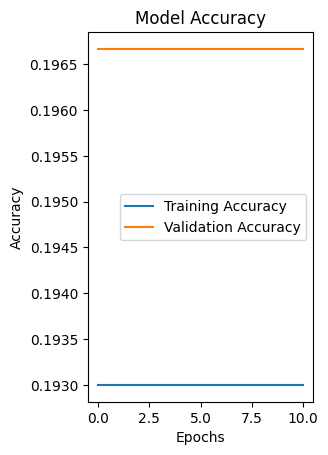

In [13]:
# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


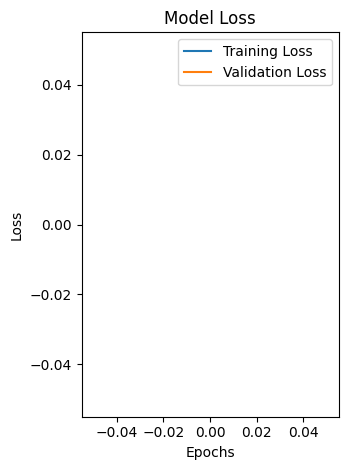

In [14]:
# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


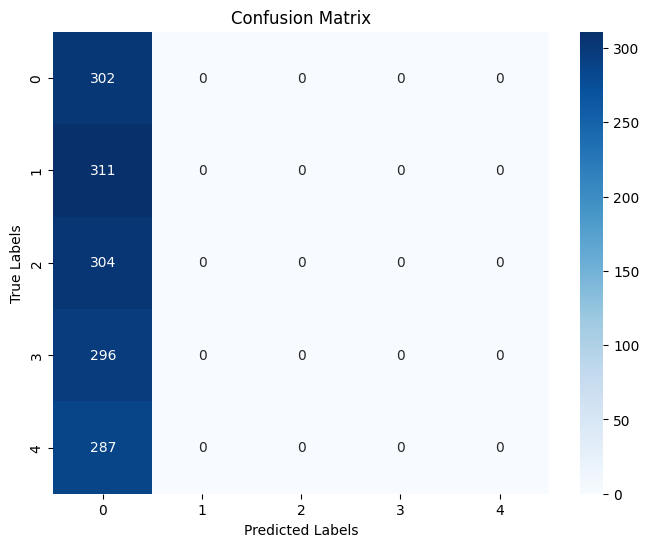

In [15]:
# Step 7: Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Convert predictions to class labels
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [16]:
# Print detailed classification report
print(classification_report(y_true_classes, y_pred_classes))


              precision    recall  f1-score   support

           0       0.20      1.00      0.34       302
           1       0.00      0.00      0.00       311
           2       0.00      0.00      0.00       304
           3       0.00      0.00      0.00       296
           4       0.00      0.00      0.00       287

    accuracy                           0.20      1500
   macro avg       0.04      0.20      0.07      1500
weighted avg       0.04      0.20      0.07      1500



C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()